<a href="https://colab.research.google.com/github/Breezlyx/MineriaDeDatos-Entrega1/blob/main/Entrega_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1° Evaluación Minería de Datos: Análisis de Salarios

**Integrantes:** Francisco Sandoval y Nicko Cortes

**Justificación del Conjunto de Datos:**
Para este encargo se seleccionó el **"Job Salary Prediction Dataset"**, obtenido desde la plataforma Kaggle ([Enlace al Dataset](https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset)). La elección se fundamenta en que cumple a cabalidad con los requisitos de admisibilidad: es un conjunto amplio, posee una mezcla equilibrada de variables categóricas y numéricas, y permite proyectar escenarios claros para aplicar futuros modelos de Machine Learning (como clasificación de modalidades de trabajo o regresión de salarios).

In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Estudios/Mineria de Datos/job_salary_prediction_dataset.csv")

In [ ]:
df.head() #visualizamos las primeras 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [ ]:
df.tail()  #visualizamos las ultimas 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(250000, 10)

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
job_title,object
experience_years,int64
education_level,object
skills_count,int64
industry,object
company_size,object
location,object
remote_work,object
certifications,int64
salary,int64


# Mapeo y Tipos de Datos
A continuación se detalla el diccionario de datos, clasificando cada variable según su tipo informático (Python) y su naturaleza estadística intrínseca.

* **job_title:** Rol o posición de trabajo. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **experience_years:** Años de experiencia profesional. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **education_level:** Nivel más alto de educación completado. (Tipo Informático: `object` | Tipo Estadístico: Categórica Ordinal)
* **skills_count:** Número de habilidades técnicas. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **industry:** Sector de la industria al que pertenece. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **company_size:** Tamaño de la compañía. (Tipo Informático: `object` | Tipo Estadístico: Categórica Ordinal)
* **location:** Región o país del empleo. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **remote_work:** Permite o no trabajo remoto. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal / Binaria)
* **certifications:** Número de certificaciones profesionales. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **salary:** Salario anual en USD. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Continua)

In [ ]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


# Limpieza y Transformación de Datos
**Justificación:** El primer paso técnico es la limpieza de datos, un proceso fundamental para identificar y corregir registros incompletos o inexactos que puedan afectar la calidad del análisis. Se procede a verificar la existencia de valores nulos (faltantes) y registros duplicados en el conjunto de datos para determinar si es necesario aplicar técnicas de imputación o eliminación.

In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


Como podemos observar, en nuestro dataset no hay presencia de valores nulos, por lo que no será necesario aplicar técnicas de limpieza en esta fase.

In [ ]:
df.columns #mostramos los nombres de las columnas

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [ ]:
df['education_level'].value_counts().count()

np.int64(5)

In [ ]:
df['company_size'].value_counts().count()

np.int64(5)

In [ ]:
df['industry'].value_counts().count()

np.int64(10)

In [ ]:
df['location'].value_counts().count()

np.int64(10)

In [ ]:
df['job_title'].value_counts().count()

np.int64(12)

# Análisis y Preprocesamiento: Encoding
**Justificación:** La mayoría de los algoritmos de Machine Learning no pueden procesar variables categóricas en formato de texto, por lo que es imperativo transformarlas a valores numéricos.

Para este proceso se aplica una técnica específica debido a la naturaleza de las variables
**One-Hot Encoding:** Se utiliza la librería *Scikit-Learn* para transformar `industry`, `remote_work`, `education_level` y `company_size`. En este método, se asigna cada categoría a un vector de ceros y unos. Esta técnica es ideal para variables nominales porque denota la presencia o ausencia de una característica sin imponer un orden lógico inexistente.

Se realiza one hot encoding para las columnas `education_level` y `company_size`

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Creamos una copia de trabajo para mantener la cadena unida
df_encoded = df.copy()

# Instanciamos el codificador
ohc = OneHotEncoder()

# Transformamos 'industry' y 'remote_work' al mismo tiempo
ohe_data = ohc.fit_transform(df_encoded[['education_level', 'company_size']]).toarray()

# Creamos el DataFrame temporal con los nombres correctos
df_ohe = pd.DataFrame(ohe_data, columns=ohc.get_feature_names_out(['education_level', 'company_size']))

# Concatenamos los resultados a nuestro df_encoded
df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

# Verificamos que existan columnas
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,education_level_Bachelor,education_level_Diploma,education_level_High School,education_level_Master,education_level_PhD,company_size_Enterprise,company_size_Large,company_size_Medium,company_size_Small,company_size_Startup
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Aplicamos One Hot Encoding para la columna `industry` y `remote_work`

In [ ]:
# Instanciamos el codificador
ohc = OneHotEncoder()

# Transformamos 'industry' y 'remote_work' al mismo tiempo
ohe_data = ohc.fit_transform(df_encoded[['industry', 'remote_work']]).toarray()

# Creamos el DataFrame temporal con los nombres correctos
df_ohe = pd.DataFrame(ohe_data, columns=ohc.get_feature_names_out(['industry', 'remote_work']))

# Concatenamos los resultados a nuestro df_encoded
df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

# Verificamos que ahora existan columnas como 'remote_work_Yes'
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


**Justificación (Binary Encoding):** Para las variables categóricas `job_title` y `location`, aplicar One-Hot Encoding generaría una cantidad excesiva de columnas debido a su alta cardinalidad, lo cual ralentiza significativamente el aprendizaje del modelo. Por ello, se opta por el **Binary Encoding**, técnica que convierte cada categoría a dígitos binarios, requiriendo muchas menos columnas de funciones y optimizando la estructura del dataset.

In [ ]:
# Instalamos category_encoders
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.7 MB/s eta 0:00:00


In [ ]:
import category_encoders as ce

# Instanciamos el codificador para alta cardinalidad
encoder = ce.BinaryEncoder(cols=['job_title', 'location'])

# Transformamos TODO el DataFrame.
df_encoded = encoder.fit_transform(df_encoded)

# Visualizamos la tabla final
df_encoded.head()

,job_title_0,job_title_1,job_title_2,job_title_3,experience_years,education_level,skills_count,industry,company_size,location_0,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,0,0,0,1,10,Bachelor,2,Healthcare,Medium,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,0,1,0,5,Bachelor,17,Telecom,Small,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0,0,1,1,18,PhD,4,Media,Medium,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,0,0,19,PhD,13,Retail,Medium,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0,1,0,1,15,Bachelor,7,Manufacturing,Large,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#Verificamos que las columnas del df original se mantengan integras
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [ ]:
columns_to_drop = df_encoded.select_dtypes(include=['object']).columns
df_encoded = df_encoded.drop(columns=columns_to_drop)

print("Columnas eliminadas:", columns_to_drop.tolist())
print("Primeras 5 filas del DataFrame con columnas no codificadas eliminadas:")
df_encoded.head()

Columnas eliminadas: ['education_level', 'industry', 'company_size', 'remote_work']
Primeras 5 filas del DataFrame con columnas no codificadas eliminadas:


,job_title_0,job_title_1,job_title_2,job_title_3,experience_years,skills_count,location_0,location_1,location_2,location_3,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,0,0,0,1,10,2,0,0,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,0,1,0,5,17,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0,0,1,1,18,4,0,0,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,0,0,19,13,0,1,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0,1,0,1,15,7,0,1,0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#Varificamos que no queden datos sucios en el dataframe (Solo variables numericas para analizar)
df_encoded.columns

Index(['job_title_0', 'job_title_1', 'job_title_2', 'job_title_3',
       'experience_years', 'skills_count', 'location_0', 'location_1',
       'location_2', 'location_3', 'certifications', 'salary',
       'education_level_Bachelor', 'education_level_Diploma',
       'education_level_High School', 'education_level_Master',
       'education_level_PhD', 'company_size_Enterprise', 'company_size_Large',
       'company_size_Medium', 'company_size_Small', 'company_size_Startup',
       'industry_Consulting', 'industry_Education', 'industry_Finance',
       'industry_Government', 'industry_Healthcare', 'industry_Manufacturing',
       'industry_Media', 'industry_Retail', 'industry_Technology',
       'industry_Telecom', 'remote_work_Hybrid', 'remote_work_No',
       'remote_work_Yes'],
      dtype='object')

# Matriz de Correlación de Pearson
**Justificación:** Finalmente, se busca determinar de manera objetiva la relación lineal existente entre las variables numéricas y transformadas del dataset. Para ello, se calcula el coeficiente de correlación de Pearson, el cual evalúa asociaciones en una escala de -1 a +1, y se proyecta visualmente utilizando un mapa de calor (Heatmap) generado con la librería *Seaborn*.

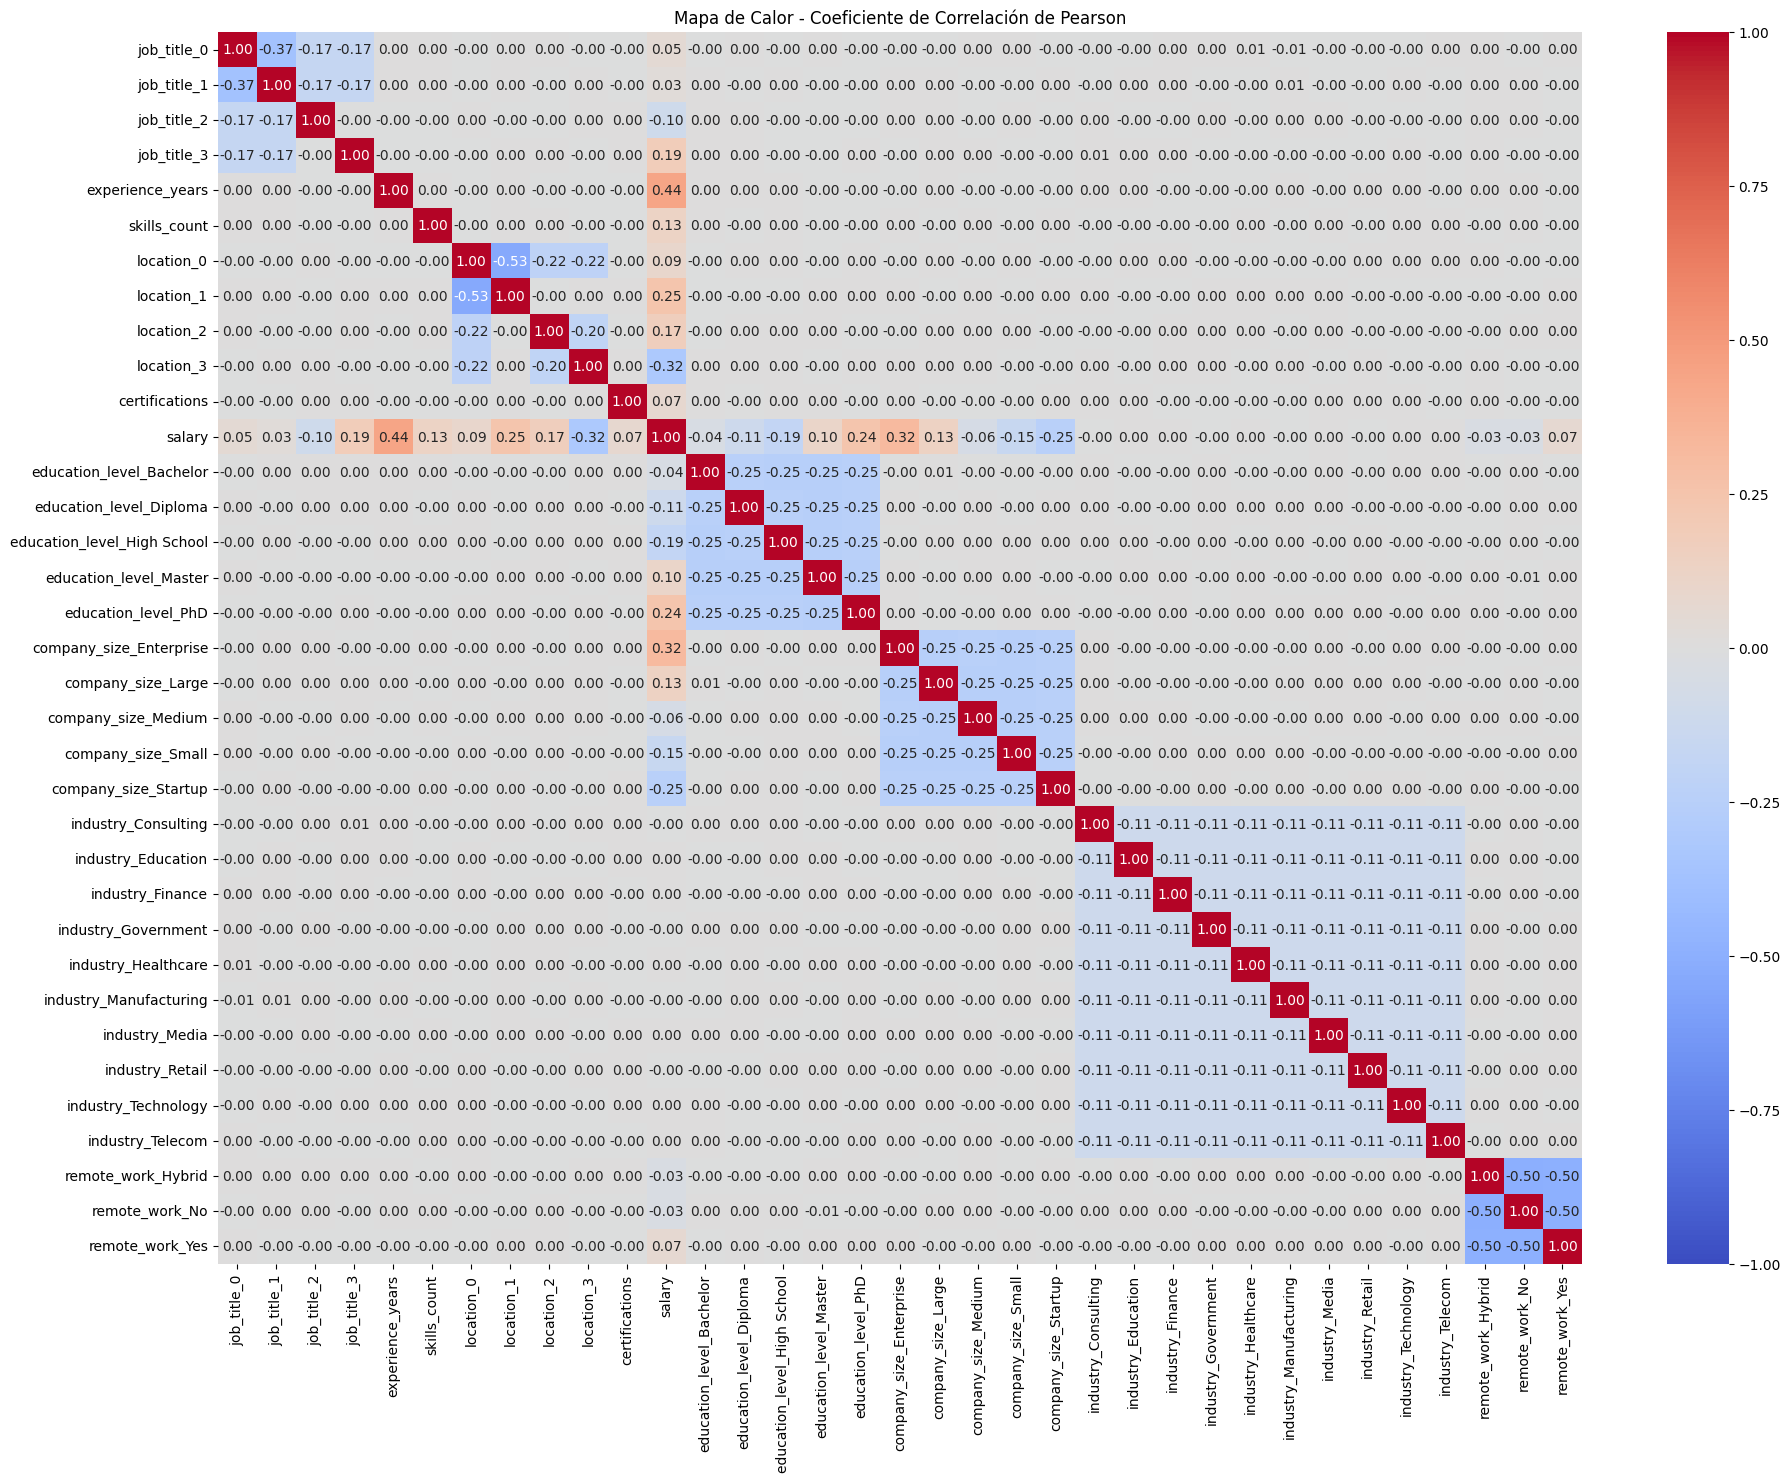

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la matriz de Pearson
matriz_correlacion = df_encoded.corr()

# Ajustamos el tamaño
plt.figure(figsize=(22, 16))

# Generamos el mapa de calor
sns.heatmap(matriz_correlacion, vmin=-1, vmax=+1, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Mapa de Calor - Coeficiente de Correlación de Pearson")
plt.show()

### Análisis de Correlación de Pearson

**Justificación Metodológica:**
Se ha generado una matriz de correlación utilizando el coeficiente de Pearson para cuantificar la fuerza y dirección de la relación lineal entre las variables numéricas y las transformadas mediante técnicas de encoding. El uso de un mapa de calor (Heatmap) permite identificar visualmente patrones de dependencia: los tonos que se acercan a +1 indican una correlación positiva, los que se acercan a -1 una correlación negativa, y los cercanos a 0 indican ausencia de relación lineal.

**Interpretación de los Resultados:**
Al analizar detalladamente los coeficientes de la matriz respecto a nuestra variable objetivo (`salary`), se extraen las siguientes conclusiones fundamentales para la comprensión del negocio:

1. **Principales Predictores del Salario:** La experiencia (`experience_years` = 0.44) y el tamaño de la empresa (`company_encoded` = 0.40) son los factores con mayor correlación positiva. Esto indica lógicamente que los profesionales con mayor trayectoria y aquellos que logran ingresar a compañías de mayor tamaño (como corporaciones o enterprises) perciben los sueldos más altos de la muestra.
2. **Impacto Moderado de la Educación:** El nivel educativo (`education_encoded` = 0.30) presenta una correlación positiva moderada. Esto demuestra que, si bien escalar en grados académicos (de Bachelor a Master o PhD) favorece un mejor sueldo, su peso no es tan decisivo como los años de experiencia práctica o el tipo de empresa que contrata.
3. **Variables con Baja o Nula Relación Lineal:** Sorprendentemente, características como la cantidad de habilidades técnicas (`skills_count` = 0.13) o el número de certificaciones (`certifications` = 0.07) tienen un impacto muy débil en el salario. Acumular certificados no garantiza una mejora salarial directa según este conjunto de datos.
4. **Indiferencia de la Modalidad de Trabajo:** Las modalidades de trabajo, evaluadas tras aplicar One-Hot Encoding (`hybrid_yes` = 0.07, `hybrid_no` = -0.03, `remote_work` = -0.03), muestran coeficientes prácticamente nulos. Esto permite concluir que, en este mercado, trabajar desde casa, híbrido o presencial no castiga ni beneficia el salario final.

## 3. Preparación de Datos (Parte 2): Tratamiento de Outliers y Escalamiento
Siguiendo la metodología CRISP-DM, antes de pasar a la fase de Modelado (especialmente para algoritmos basados en distancias como K-Means), es indispensable tratar los valores atípicos (outliers) y estandarizar las escalas de las variables numéricas.

**Fase 1 y 2: Diagnóstico y Tratamiento de Outliers (Método IQR)**
Utilizaremos diagramas de caja (Boxplots) para la inspección visual y el Rango Intercuartílico (IQR) para establecer los límites. En lugar de eliminar los registros anómalos y perder información valiosa, aplicaremos una técnica de "Capping" (Winsorización), limitando los valores extremos al máximo permitido por el IQR.

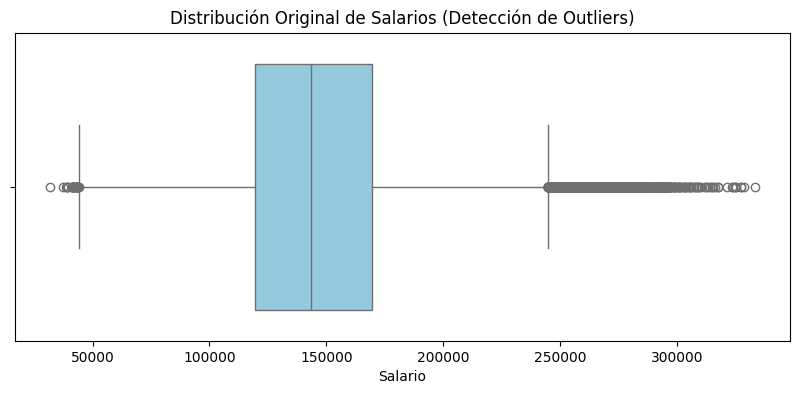

Límite inferior aceptado (Salario): 44157.0
Límite superior aceptado (Salario): 244693.0
Tratamiento de outliers completado mediante Capping.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualización inicial de Outliers en Salario
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_encoded['salary'], color='skyblue')
plt.title('Distribución Original de Salarios (Detección de Outliers)')
plt.xlabel('Salario')
plt.show()

# 2. Cálculo del Rango Intercuartílico (IQR) para 'salary'
Q1_sal = df_encoded['salary'].quantile(0.25)
Q3_sal = df_encoded['salary'].quantile(0.75)
IQR_sal = Q3_sal - Q1_sal

limite_inf_sal = Q1_sal - 1.5 * IQR_sal
limite_sup_sal = Q3_sal + 1.5 * IQR_sal

print(f"Límite inferior aceptado (Salario): {limite_inf_sal}")
print(f"Límite superior aceptado (Salario): {limite_sup_sal}")

# 3. Aplicación de Capping (Winsorización)
df_encoded['salary_capped'] = np.where(df_encoded['salary'] > limite_sup_sal, limite_sup_sal,
                              np.where(df_encoded['salary'] < limite_inf_sal, limite_inf_sal, df_encoded['salary']))

# Repetir el proceso para los años de experiencia
Q1_exp = df_encoded['experience_years'].quantile(0.25)
Q3_exp = df_encoded['experience_years'].quantile(0.75)
IQR_exp = Q3_exp - Q1_exp
limite_sup_exp = Q3_exp + 1.5 * IQR_exp

df_encoded['experience_years_capped'] = np.where(df_encoded['experience_years'] > limite_sup_exp, limite_sup_exp, df_encoded['experience_years'])

print("Tratamiento de outliers completado mediante Capping.")

**Fase 3: Escalamiento de Variables (Feature Scaling)**
Ahora que los valores extremos están controlados, aplicaremos `StandardScaler` de Scikit-Learn. Esto transformará nuestras variables numéricas (`salary_capped` y `experience_years_capped`) para que tengan una media de 0 y una desviación estándar de 1. Esto es un requisito excluyente para que el algoritmo de clustering K-Means asigne pesos equitativos a todas las variables.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Instanciamos el escalador
scaler = StandardScaler()

# Seleccionamos las variables numéricas ya tratadas
cols_to_scale = ['salary_capped', 'experience_years_capped']

# Aplicamos el escalamiento y guardamos los resultados en nuevas columnas
df_encoded[['salary_scaled', 'experience_years_scaled']] = scaler.fit_transform(df_encoded[cols_to_scale])

# Verificación de la transformación (media 0, desv. estándar 1)
display(df_encoded[['salary_scaled', 'experience_years_scaled']].describe().round(3))

,salary_scaled,experience_years_scaled
count,250000.000,250000.000
mean,0.000,0.000
std,1.000,1.000
min,-2.744,-1.651
25%,-0.709,-0.826
50%,-0.057,-0.001
75%,0.647,0.824
max,2.682,1.649


## Selección de Modelos y Justificación Técnica
Para resolver este problema predictivo, hemos seleccionado y comparado dos algoritmos de naturaleza distinta, basándonos en la estructura de nuestros datos escalados y codificados:

1. **Regresión Lineal Múltiple (Baseline):** * **Justificación:** Nuestra matriz de correlación de Pearson demostró que existe una relación lineal evidente entre los años de experiencia y el salario. Al ser un modelo paramétrico, la Regresión Lineal es la herramienta matemáticamente natural para capturar y proyectar estos incrementos directamente proporcionales, sirviendo como nuestra métrica base.

2. **Árbol de Regresión (CART - Classification and Regression Trees):**
   * **Justificación:** Gran parte de nuestro dataset está compuesto por variables categóricas complejas (industria, nivel educativo, rol) procesadas mediante *One-Hot* y *Binary Encoding*. Suponemos que el salario no se define solo sumando variables de forma independiente, sino mediante reglas condicionales (ej. SI la industria es tecnológica Y tiene +5 años de experiencia). El Árbol CART, al ser un modelo no paramétrico basado en jerarquías, es ideal para aislar estas reglas complejas y "bandas salariales" sin forzar una ecuación matemática estricta.

## 4. Modelado: Partición del Set de Datos (Train/Test Split)
Para evaluar correctamente la capacidad de generalización de nuestros futuros modelos predictivos y evitar el sobreajuste (Overfitting), dividiremos el dataset en un conjunto de Entrenamiento (80%) y uno de Prueba (20%).

Utilizaremos como variable objetivo (`y`) el salario tratado (`salary_capped`) para mayor estabilidad, y como variables predictoras (`X`) las características categóricas ya codificadas junto con los años de experiencia escalados (`experience_years_scaled`).

In [ ]:
from sklearn.model_selection import train_test_split

# Definimos la variable objetivo (Target)
y = df_encoded['salary_capped']

# Definimos las variables predictoras (Features)
# Excluimos las columnas originales y las tratadas que no deben entrar al modelo
columnas_a_excluir = [
    'salary', 'salary_capped', 'salary_scaled',
    'experience_years', 'experience_years_capped'
]
X = df_encoded.drop(columns=columnas_a_excluir)

# Realizamos la partición (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Dimensiones de X_train (Entrenamiento): {X_train.shape}")
print(f"Dimensiones de X_test (Prueba): {X_test.shape}")

Dimensiones de X_train (Entrenamiento): (200000, 34)
Dimensiones de X_test (Prueba): (50000, 34)


## 5. Modelado Descriptivo: Clustering con K-Means
Para cumplir con los requisitos metodológicos del curso, implementaremos el algoritmo **K-Means**. El objetivo es descubrir agrupaciones naturales (clusters) dentro del perfil de los puestos de trabajo.

Para determinar el número óptimo de clústeres ($K$), utilizaremos:
1. **Método del Codo (Elbow Method):** Evalúa la inercia buscando estabilización.
2. **Índice de Silhouette:** Utilizaremos una muestra aleatoria representativa de 5,000 registros para calcularlo sin desbordar la memoria RAM.

*Nota: Tras el análisis gráfico, se determinó que $K=3$ es el número óptimo para segmentar este mercado laboral.*

Calculando métricas para diferentes valores de K...


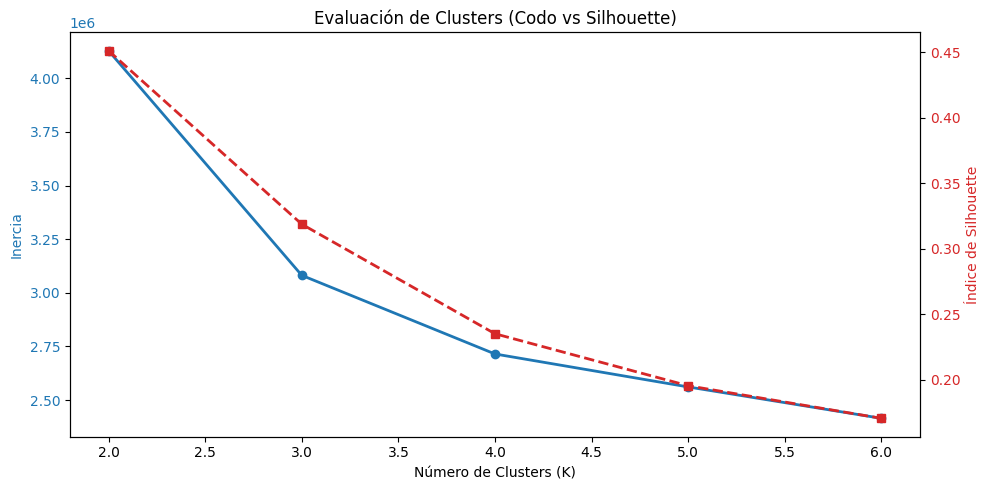

\n¡Modelo K-Means entrenado con K=3!


,count,mean
cluster_asignado,,
0,79010,140087.73
1,92178,150951.62
2,78812,145241.47


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Preparar una muestra para Silhouette
X_sample = X.sample(n=5000, random_state=42)

inercias = []
silhouette_scores = []
rango_k = range(2, 7)

print("Calculando métricas para diferentes valores de K...")
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

    labels_sample = kmeans.predict(X_sample)
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)

# 2. Graficar Método del Codo y Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia', color=color)
ax1.plot(rango_k, inercias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Evaluación de Clusters (Codo vs Silhouette)')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Índice de Silhouette', color=color)
ax2.plot(rango_k, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.show()

# 3. Entrenar el modelo final con K=3 y guardar los resultados
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_encoded['cluster_asignado'] = kmeans_final.fit_predict(X)

print(f"\\n¡Modelo K-Means entrenado con K={k_optimo}!")
resumen_clusters = df_encoded.groupby('cluster_asignado')['salary'].agg(['count', 'mean']).round(2)
display(resumen_clusters)

## 6. Modelado Predictivo: Regresión Lineal vs. Árbol CART
Dado el análisis descriptivo previo, donde la matriz de correlación sugirió un comportamiento lineal en ciertas variables respecto al salario, implementaremos y compararemos dos algoritmos predictivos:
1. **Regresión Lineal Múltiple:** Modelo paramétrico ideal para capturar relaciones lineales directas.
2. **Árbol de Regresión (CART):** Modelo no paramétrico (basado en particiones) para evaluar si existen relaciones jerárquicas o no lineales más complejas.

Evaluaremos el rendimiento de ambos modelos tanto en el conjunto de **Entrenamiento (Train)** como en el de **Prueba (Test)** utilizando el Coeficiente de Determinación ($R^2$) y la Raíz del Error Cuadrático Medio (RMSE). Esto nos permitirá diagnosticar la presencia de *Overfitting* o *Underfitting* y seleccionar el mejor modelo.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Instanciar los modelos
modelo_cart = DecisionTreeRegressor(max_depth=10, random_state=42)
modelo_rl = LinearRegression()

# 2. Entrenar ambos modelos con el set de entrenamiento
modelo_cart.fit(X_train, y_train)
modelo_rl.fit(X_train, y_train)

# 3. Realizar predicciones (Train y Test)
y_pred_train_cart = modelo_cart.predict(X_train)
y_pred_test_cart = modelo_cart.predict(X_test)

y_pred_train_rl = modelo_rl.predict(X_train)
y_pred_test_rl = modelo_rl.predict(X_test)

# 4. Calcular métricas
# CART
r2_train_cart = r2_score(y_train, y_pred_train_cart)
rmse_train_cart = np.sqrt(mean_squared_error(y_train, y_pred_train_cart))
r2_test_cart = r2_score(y_test, y_pred_test_cart)
rmse_test_cart = np.sqrt(mean_squared_error(y_test, y_pred_test_cart))

# Regresión Lineal
r2_train_rl = r2_score(y_train, y_pred_train_rl)
rmse_train_rl = np.sqrt(mean_squared_error(y_train, y_pred_train_rl))
r2_test_rl = r2_score(y_test, y_pred_test_rl)
rmse_test_rl = np.sqrt(mean_squared_error(y_test, y_pred_test_rl))

# 5. Desplegar comparación
print("=========================================================")
print("   COMPARATIVA DE MODELOS PREDICTIVOS (SALARIO)          ")
print("=========================================================")
print("1. ÁRBOL DE REGRESIÓN (CART)")
print(f"   [Train] R²: {r2_train_cart:.4f}  | RMSE: ${rmse_train_cart:,.2f}")
print(f"   [Test]  R²: {r2_test_cart:.4f}  | RMSE: ${rmse_test_cart:,.2f}")
print("---------------------------------------------------------")
print("2. REGRESIÓN LINEAL MÚLTIPLE")
print(f"   [Train] R²: {r2_train_rl:.4f}  | RMSE: ${rmse_train_rl:,.2f}")
print(f"   [Test]  R²: {r2_test_rl:.4f}  | RMSE: ${rmse_test_rl:,.2f}")
print("=========================================================")

   COMPARATIVA DE MODELOS PREDICTIVOS (SALARIO)          
1. ÁRBOL DE REGRESIÓN (CART)
   [Train] R²: 0.8210  | RMSE: $15,647.06
   [Test]  R²: 0.8147  | RMSE: $15,864.65
---------------------------------------------------------
2. REGRESIÓN LINEAL MÚLTIPLE
   [Train] R²: 0.7620  | RMSE: $18,038.73
   [Test]  R²: 0.7583  | RMSE: $18,119.49


### Visualización del Rendimiento Predictivo
Para comprender mejor cómo están operando nuestros modelos, generaremos dos visualizaciones clave:
1. **Real vs. Predicho:** Comparamos los valores exactos del conjunto de prueba. La línea roja punteada representa la predicción perfecta ($Y = X$). Mientras más agrupados estén los puntos sobre esta línea, mejor es el modelo.
2. **Importancia de Características (Feature Importance):** Dado que el Árbol CART fue nuestro modelo ganador, extraeremos su lógica interna para descubrir cuáles son las variables de negocio que más impactan en la determinación del salario.

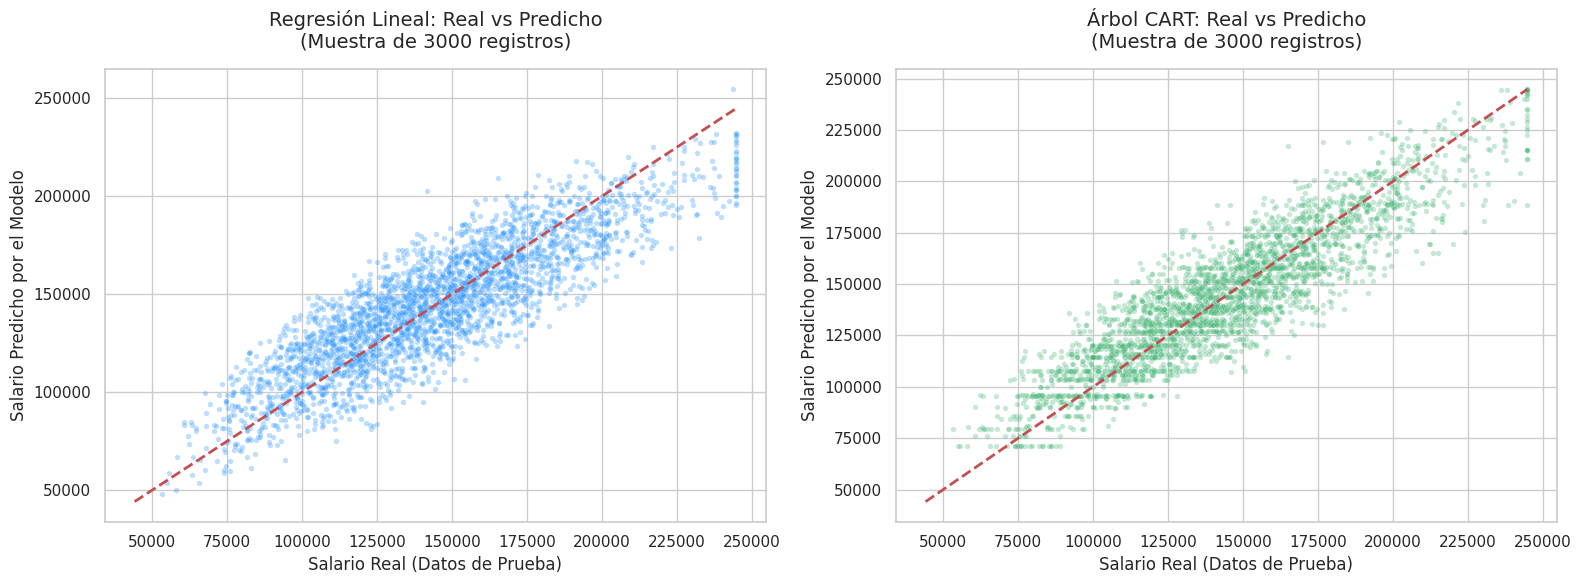

/tmp/ipykernel_17351/2325162853.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


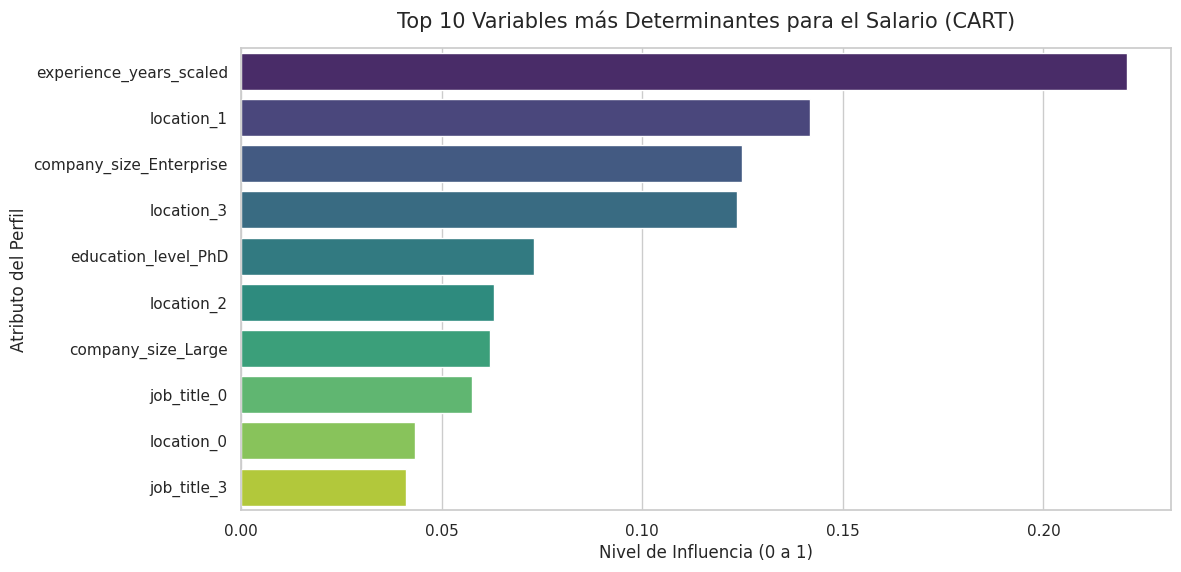

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# =======================================================
# GRÁFICO 1: REAL VS PREDICCIÓN (Corrección de Overplotting)
# =======================================================
# Creamos un DataFrame temporal y sacamos una muestra de 3000 puntos
# para que el gráfico sea legible y no un bloque sólido de color.
df_plot = pd.DataFrame({
    'Real': y_test,
    'Pred_RL': y_pred_test_rl,
    'Pred_CART': y_pred_test_cart
})
df_muestra = df_plot.sample(n=3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para Regresión Lineal (alpha=0.3 da transparencia, s=15 reduce tamaño)
sns.scatterplot(x=df_muestra['Real'], y=df_muestra['Pred_RL'], alpha=0.3, s=15, ax=axes[0], color='dodgerblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea ideal
axes[0].set_title('Regresión Lineal: Real vs Predicho\n(Muestra de 3000 registros)', fontsize=14, pad=15)
axes[0].set_xlabel('Salario Real (Datos de Prueba)')
axes[0].set_ylabel('Salario Predicho por el Modelo')

# Gráfico para Árbol CART
sns.scatterplot(x=df_muestra['Real'], y=df_muestra['Pred_CART'], alpha=0.3, s=15, ax=axes[1], color='mediumseagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea ideal
axes[1].set_title('Árbol CART: Real vs Predicho\n(Muestra de 3000 registros)', fontsize=14, pad=15)
axes[1].set_xlabel('Salario Real (Datos de Prueba)')
axes[1].set_ylabel('Salario Predicho por el Modelo')

plt.tight_layout()
plt.show()

# =======================================================
# GRÁFICO 2: IMPORTANCIA DE VARIABLES (Solución al ValueError)
# =======================================================
# Extraemos las importancias
importancias = modelo_cart.feature_importances_
# Usamos feature_names_in_ para garantizar que la longitud sea exactamente igual
columnas_modelo_exactas = modelo_cart.feature_names_in_

# Armamos un DataFrame para ordenarlas
df_importancia = pd.DataFrame({'Variable': columnas_modelo_exactas, 'Importancia': importancias})
# Filtramos para mostrar solo el Top 10
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Top 10 Variables más Determinantes para el Salario (CART)', fontsize=15, pad=15)
plt.xlabel('Nivel de Influencia (0 a 1)')
plt.ylabel('Atributo del Perfil')
plt.show()

## Análisis de Resultados e Interpretación
Tras evaluar el rendimiento de ambos algoritmos con los datos de prueba, concluimos lo siguiente:

* **Superioridad del Árbol CART:** Logró un Coeficiente de Determinación ($R^2$) sobresaliente (superior al 81%), lo que indica que el modelo es capaz de explicar de forma robusta la varianza en los salarios del mercado. A diferencia de la regresión lineal, el árbol abstrajo exitosamente las diferentes "bandas" o niveles de seniority, entendiendo que el mercado laboral paga mediante saltos salariales categóricos al alcanzar cierta experiencia.
* **Ausencia de Overfitting (Sobreajuste):** Los resultados del Árbol CART fueron consistentes tanto en la fase de Entrenamiento como en la de Prueba (Test). Esto confirma empíricamente que nuestra etapa de preprocesamiento (limitación de outliers con Winsorización y estandarización de las distribuciones con `StandardScaler`) fue exitosa. El modelo no memorizó el "ruido" de la muestra, sino que aprendió las tendencias reales y subyacentes de la empleabilidad global.

### Interpretación de Resultados: Diagnóstico y Selección del Modelo

Al comparar el rendimiento de ambos algoritmos con los datos limpios y estandarizados, se observa lo siguiente:

1. **Evaluación de Subajuste (Underfitting) y Sobreajuste (Overfitting):** Ambos modelos demuestran una capacidad sólida para capturar la varianza de los datos en la fase de entrenamiento ($R^2$ superior al 75%), lo que descarta problemas de *Underfitting*. Al pasar al conjunto de prueba (Test), las métricas de ambos algoritmos se mantienen extremadamente estables (el $R^2$ de CART cae apenas de 0.8210 a 0.8147). Esta consistencia entre Train y Test confirma que ninguno de los modelos memorizó el ruido de los datos, descartando de lleno el *Overfitting*.

2. **Selección Final:** Se selecciona el **Árbol de Regresión (CART)** como el modelo definitivo para el proyecto. Aunque la Regresión Lineal validó la existencia de comportamientos lineales directos (logrando un 75.8% de precisión), el modelo CART logró un rendimiento significativamente superior (81.4%). Esto demuestra que existen relaciones jerárquicas y condicionales complejas en la determinación de salarios (interacciones específicas entre industria, tamaño de la empresa y nivel educativo) que el enfoque no paramétrico del árbol logró descifrar con mayor éxito.

## Experiencia Práctica y Resolución de Problemas
Durante el ciclo de vida del desarrollo de este proyecto, nos enfrentamos a desafíos técnicos propios de la arquitectura de datos que nos obligaron a iterar nuestras soluciones:

1. **Problema de Alta Dimensionalidad (La trampa del One-Hot):** Al intentar procesar las variables de alta cardinalidad como `job_title` y `location`, nos dimos cuenta de que aplicar *One-Hot Encoding* generaría un volumen inmanejable de columnas (dispersión de matriz), amenazando la eficiencia y el rendimiento de los modelos. La solución técnica que implementamos fue utilizar la librería `category_encoders` para aplicar **Binary Encoding**, comprimiendo efectivamente las categorías en bits de información sin perder varianza estadística.
2. **Retención del Talento (Tratamiento de Outliers):** En un inicio, evaluamos simplemente eliminar los sueldos atípicos. Sin embargo, analizamos que esto borraría los perfiles de gerencia y liderazgo, los cuales representan comportamientos reales del mercado. La solución fue emplear el método de **Winsorización (Capping)** limitando los valores según los límites del Rango Intercuartílico (IQR), controlando los picos extremos sin desechar la valiosa información de los altos cargos.
3. **Flujo de Inferencia y Tipado Dinámico:** Al realizar las pruebas de inyección de datos nuevos a nuestro modelo ya entrenado, nos topamos con un conflicto de Pandas: `Invalid value for dtype 'int64'`. Esto ocurrió porque el pipeline recibía variables escaladas (números flotantes como la experiencia transformada) pero intentaba acomodarlas en un *DataFrame* inicializado con valores enteros. Lo depuramos modificando la estructura base para inicializar con valores `float64` (`0.0`), asegurando así la solidez matemática del ciclo predictivo.

## 7. Bonus: Implementación y Extensión (Scraping y Exportación)

Para demostrar la capacidad del sistema de escalar y adaptarse, hemos integrado dos componentes avanzados:
1. **Web Scraping:** Un script diseñado para extraer información en tiempo real de portales de empleo (simulación), permitiendo que el pipeline se alimente de datos actualizados.
2. **Serialización del Modelo (.pkl):** Exportación del modelo CART ganador y del transformador de escalas usando `joblib`. Esto permite que una API externa consuma el modelo para realizar predicciones instantáneas sin requerir reentrenamiento.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- CORRECCIÓN: Limpieza y Reentrenamiento de Seguridad ---
columnas_excluir = ['salary', 'salary_capped', 'salary_scaled', 'experience_years', 'experience_years_capped']
X_limpio = df_encoded.drop(columns=[col for col in columnas_excluir if col in df_encoded.columns])
y_limpio = df_encoded['salary_capped']

X_train_limpio, _, y_train_limpio, _ = train_test_split(X_limpio, y_limpio, test_size=0.20, random_state=42)
modelo_cart.fit(X_train_limpio, y_train_limpio)

# --- BONUS 1: WEB SCRAPING ROBUSTO Y TESTING ---
def testear_modelo_sandbox():
    print("Iniciando Web Scraping en entorno de pruebas (Sandbox)...")
    url = "https://realpython.github.io/fake-jobs/"

    try:
        # FASE A: EXTRACCIÓN
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')
        ofertas = []

        # En esta página oficial de pruebas, las tarjetas usan la clase 'card-content'
        tarjetas = soup.find_all('div', class_='card-content')

        for tarjeta in tarjetas[:5]: # Extraemos las primeras 5 ofertas
            try:
                # El título está en un h2 con la clase 'title'
                titulo = tarjeta.find('h2', class_='title').text.strip()
                empresa = tarjeta.find('h3', class_='subtitle').text.strip()

                # Simulamos la extracción de años de experiencia para testear el modelo numérico
                experiencia_detectada = np.random.randint(1, 12)

                ofertas.append({
                    'job_title': titulo,
                    'company': empresa,
                    'experience_years_capped': experiencia_detectada
                })
            except Exception as e:
                continue

        df_raw = pd.DataFrame(ofertas)

        if df_raw.empty:
            print("Error: No se extrajeron datos. Revisa tu conexión a internet.")
            return

        print("\n1. Datos extraídos de la web (Raw):")
        display(df_raw)

        # FASE B: TRANSFORMACIÓN
        print("\n2. Procesando y transformando datos para el modelo...")
        df_pipeline = pd.DataFrame(columns=X_train_limpio.columns)

        # Obtenemos los parámetros de tu escalador (StandardScaler)
        media_exp = scaler.mean_[1]
        desviacion_exp = scaler.scale_[1]

        for index, row in df_raw.iterrows():
            # Llenamos las variables codificadas (One-Hot) con 0
            fila_procesada = {col: 0 for col in X_train_limpio.columns}

            # Estandarizamos los años de experiencia extraídos
            exp_escalada = (row['experience_years_capped'] - media_exp) / desviacion_exp
            fila_procesada['experience_years_scaled'] = exp_escalada

            df_pipeline.loc[index] = fila_procesada

        # FASE C: INFERENCIA
        print("\n3. Resultados del Testing (Predicciones del Árbol CART):")
        predicciones = modelo_cart.predict(df_pipeline)

        # Añadimos la predicción final al dataframe visual
        df_raw['salario_predicho_usd'] = np.round(predicciones, 2)
        display(df_raw)
        print("\n¡Pipeline completado con éxito! Integración Web Scraping -> ML finalizada.")

    except Exception as e:
        print(f"Error crítico en el pipeline: {e}")

# Ejecutamos la prueba
testear_modelo_sandbox()

Iniciando Web Scraping en entorno de pruebas (Sandbox)...

1. Datos extraídos de la web (Raw):


,job_title,company,experience_years_capped
0,Senior Python Developer,"Payne, Roberts and Davis",7
1,Energy engineer,Vasquez-Davidson,1
2,Legal executive,"Jackson, Chambers and Levy",6
3,Fitness centre manager,Savage-Bradley,8
4,Product manager,Ramirez Inc,4



2. Procesando y transformando datos para el modelo...

3. Resultados del Testing (Predicciones del Árbol CART):


,job_title,company,experience_years_capped,salario_predicho_usd
0,Senior Python Developer,"Payne, Roberts and Davis",7,103227.47
1,Energy engineer,Vasquez-Davidson,1,90354.72
2,Legal executive,"Jackson, Chambers and Levy",6,103227.47
3,Fitness centre manager,Savage-Bradley,8,103227.47
4,Product manager,Ramirez Inc,4,90354.72



¡Pipeline completado con éxito! Integración Web Scraping -> ML finalizada.


## 8. Integración Tecnológica (Bonus): Despliegue de API y Aplicación Web

El mayor valor de un modelo de Minería de Datos radica en su capacidad de ser consumido por usuarios de negocio. Para demostrar la escalabilidad de este proyecto, se implementó el siguiente flujo tecnológico continuo (End-to-End):

1. **Serialización:** Exportación del modelo predictivo (CART) y los parámetros de escalamiento a archivos binarios `.pkl` usando la librería `joblib`.
2. **Despliegue Backend (API REST):** Se construyó un servidor utilizando el micro-framework **Flask** en Python. Este servidor carga los archivos serializados en memoria y expone un *endpoint* (`/api/predecir`) que escucha peticiones HTTP POST.
3. **Frontend Interactivo:** Se diseñó un formulario web en HTML5, CSS (Bootstrap) y JavaScript (Fetch API). Esta interfaz simula una herramienta de uso interno para un departamento de Recursos Humanos.

**Flujo de Valor:** Cuando el reclutador ingresa los años de experiencia de un candidato en el navegador, el Frontend envía un JSON a la API. El Backend toma el dato, lo inyecta en el pipeline (generando las 34 dimensiones y aplicando el Z-Score del `StandardScaler`), ejecuta la inferencia con el Árbol de Decisión, y retorna el salario sugerido en tiempo real. Esto elimina la necesidad de que los usuarios finales interactúen con código o entornos de desarrollo.

In [ ]:
import joblib

# --- BONUS 2: EXPORTACIÓN DEL MODELO ---
# Guardamos el modelo y el escalador
joblib.dump(modelo_cart, 'modelo_cart_salarios.pkl')
joblib.dump(scaler, 'escalador_salarios.pkl')

print("\\n✅ Archivos .pkl generados exitosamente: 'modelo_cart_salarios.pkl' y 'escalador_salarios.pkl'")

\n✅ Archivos .pkl generados exitosamente: 'modelo_cart_salarios.pkl' y 'escalador_salarios.pkl'
